In [52]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder # for multi-class classification
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (confusion_matrix, classification_report,
							accuracy_score, precision_score, recall_score, f1_score)

In [53]:
train=pd.read_csv("./data/preprocessedTrain1.csv")
test=pd.read_csv("./data/preprocessedTest1.csv")

In [54]:
# To fill nulls for CNN
# print(train.isnull().sum())
train['f_Header_b_payload_Ratio'] = train['f_Header_b_payload_Ratio'].replace(np.nan, train['f_Header_b_payload_Ratio'].max() + 1) 
train['b_Header_f_payload_Ratio'] = train['b_Header_f_payload_Ratio'].replace(np.nan, train['b_Header_f_payload_Ratio'].max() + 1) 
# print(train.isnull().sum())
test['f_Header_b_payload_Ratio'] = test['f_Header_b_payload_Ratio'].replace(np.nan, test['f_Header_b_payload_Ratio'].max() + 1) 
test['b_Header_f_payload_Ratio'] = test['b_Header_f_payload_Ratio'].replace(np.nan, test['b_Header_f_payload_Ratio'].max() + 1) 
train

,id.orig_p,id.resp_p,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,flow_pkts_per_sec,...,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,proto_icmp,proto_udp,f_Header_b_payload_Ratio,b_Header_f_payload_Ratio,bwd_payload_zero_flg,fwd_payload_zero_flg,Attack_type
0,0.832746,0.000321,0.0,2.665046e-10,0.000282,0.000504,0.000282,0.0,0.190476,0.190476,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
1,0.715709,0.000321,0.0,2.665046e-10,0.000282,0.000504,0.000282,0.0,0.190476,0.190476,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
2,0.922972,0.000321,0.0,2.132037e-10,0.000282,0.000504,0.000282,0.0,0.250000,0.250000,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
3,0.570230,0.000321,0.0,5.330092e-11,0.000282,0.000504,0.000282,0.0,1.000000,1.000000,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
4,0.778759,0.093731,0.0,3.198055e-10,0.000282,0.000504,0.000000,0.0,0.160000,0.160000,...,0.015625,0.0,0.015625,0.0,0.0,2.0,2.000000,1.0,1.0,NMAP_OS_DETECTION
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98488,0.063005,0.000321,0.0,1.599028e-10,0.000282,0.000504,0.000282,0.0,0.307692,0.307692,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
98489,0.117723,0.000321,0.0,2.132037e-10,0.000282,0.000504,0.000282,0.0,0.235294,0.235294,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
98490,0.413428,0.000321,0.0,2.132037e-10,0.000282,0.000504,0.000282,0.0,0.235294,0.235294,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
98491,0.126421,0.000321,0.0,2.665046e-10,0.000282,0.000504,0.000282,0.0,0.190476,0.190476,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping


In [55]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train class counts:\n", train["Attack_type"].value_counts())
print("Test class counts:\n", test["Attack_type"].value_counts())

Train shape: (98493, 83)
Test shape: (24624, 83)
Train class counts:
 Attack_type
DOS_SYN_Hping                 75727
Thing_Speak                    6486
ARP_poisioning                 6200
MQTT_Publish                   3317
NMAP_UDP_SCAN                  2072
NMAP_XMAS_TREE_SCAN            1608
NMAP_OS_DETECTION              1600
NMAP_TCP_scan                   802
DDOS_Slowloris                  427
Wipro_bulb                      202
Metasploit_Brute_Force_SSH       30
NMAP_FIN_SCAN                    22
Name: count, dtype: int64
Test class counts:
 Attack_type
DOS_SYN_Hping                 18932
Thing_Speak                    1622
ARP_poisioning                 1550
MQTT_Publish                    829
NMAP_UDP_SCAN                   518
NMAP_XMAS_TREE_SCAN             402
NMAP_OS_DETECTION               400
NMAP_TCP_scan                   200
DDOS_Slowloris                  107
Wipro_bulb                       51
Metasploit_Brute_Force_SSH        7
NMAP_FIN_SCAN                   

In [56]:
def to_binary_label(y):
    # 0 = benign, 1 = malicious
    benign = ['MQTT_Publish', 'Thing_Speak', 'Wipro_bulb']
    return [0 if val in benign else 1 for val in y]

y_train = to_binary_label(train["Attack_type"])
y_test = to_binary_label(test["Attack_type"])

# TEST
X_train = train.drop("Attack_type", axis=1).values
X_test = test.drop("Attack_type", axis=1).values

In [57]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [58]:
X_train_tensor = torch.tensor(X_train_res, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_res, dtype=torch.float32).view(-1, 1)

# TEST
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [59]:
X_train_cnn = X_train_padded.view(-1, 1, 90)  # flatten 9*10 = 90
X_test_cnn = X_test_padded.view(-1, 1, 90)


train_dataset = TensorDataset(X_train_cnn, y_train_tensor)
test_dataset = TensorDataset(X_test_cnn, y_test_tensor)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [60]:
X_sample, _ = next(iter(train_loader))
print(X_sample.shape)

x, y = next(iter(train_loader))
x.shape
print(X_train_tensor.shape)

torch.Size([64, 1, 90])
torch.Size([176976, 82])


In [ ]:
class BinaryAttackCNN1D(nn.Module):
    def __init__(self, input_length, dropout_rate=0.3):
        super().__init__()
        # --- Convolutional feature extractor ---
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(16)

        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(32)

        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout1d(dropout_rate)

        # Compute flatten dimension dynamically
        self.flatten_dim = 32 * (input_length // 2)

        # --- Fully connected layers ---
        self.fc1 = nn.Linear(self.flatten_dim, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        # Convolutional block
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # Flatten for dense layers
        x = x.view(x.size(0), -1)

        # Dense block
        x = F.relu(self.fc1(self.dropout(x)))
        x = self.fc2(x)

        # Output = logits for BCEWithLogitsLoss
        return x

In [62]:
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.float()  
        y_batch = y_batch.float()

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")


Epoch [1/20], Loss: 0.0283
Epoch [2/20], Loss: 0.0272
Epoch [3/20], Loss: 0.0268
Epoch [4/20], Loss: 0.0257
Epoch [5/20], Loss: 0.0248
Epoch [6/20], Loss: 0.0241
Epoch [7/20], Loss: 0.0228
Epoch [8/20], Loss: 0.0226
Epoch [9/20], Loss: 0.0219
Epoch [10/20], Loss: 0.0213
Epoch [11/20], Loss: 0.0208
Epoch [12/20], Loss: 0.0207
Epoch [13/20], Loss: 0.0205
Epoch [14/20], Loss: 0.0198
Epoch [15/20], Loss: 0.0193
Epoch [16/20], Loss: 0.0191
Epoch [17/20], Loss: 0.0183
Epoch [18/20], Loss: 0.0183
Epoch [19/20], Loss: 0.0180
Epoch [20/20], Loss: 0.0179


In [63]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = (torch.sigmoid(outputs) > 0.5).int()  # Binary classification
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print(cm)

# Classification Report
report = classification_report(all_labels, all_preds, target_names=["Benign", "Malicious"], output_dict=True)
print(classification_report(all_labels, all_preds, target_names=["Benign", "Malicious"]))

# Convert report to DataFrame and save to CSV
report_df = pd.DataFrame(report).transpose()
report_df.to_csv("classification_reports/evaluation_metrics_cnn_binary.csv", index=True)
print("Success")

[[ 2466    36]
 [   72 22050]]
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98      2502
   Malicious       1.00      1.00      1.00     22122

    accuracy                           1.00     24624
   macro avg       0.99      0.99      0.99     24624
weighted avg       1.00      1.00      1.00     24624

Success


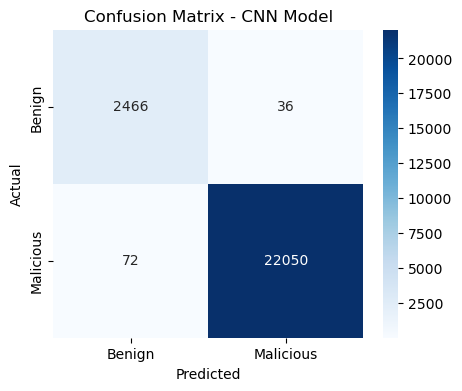

In [65]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Benign", "Malicious"], yticklabels=["Benign", "Malicious"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CNN Model")
plt.savefig("confusionmatrices/cnn_binary")
plt.show()

In [66]:
torch.save(model.state_dict(), "1dcnn_base.pth")
print("Model saved to 1dcnn_base.pth")

Model saved to 1dcnn_base.pth
